In [18]:
!pip -q install huggingface_hub scikit-learn pandas matplotlib seaborn tqdm

In [3]:
from huggingface_hub import hf_hub_download

MODEL_PATH = hf_hub_download(
    repo_id="tech0312/krishidrishti-agri-model",
    filename="best_agri_model.pth"
)

print("Model downloaded to:")
print(MODEL_PATH)

best_agri_model.pth: reconstructing file:   0%|          |  0.00B / 16.5MB            

best_agri_model.pth: downloading bytes:           |  0.00B            

Model downloaded to:
/root/.cache/huggingface/hub/models--tech0312--krishidrishti-agri-model/snapshots/0673bbf295d04f78b07c6aaa6dda4928e67d9aec/best_agri_model.pth


In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("Checkpoint loaded successfully!")
print("Keys:", checkpoint.keys())

Checkpoint loaded successfully!
Keys: dict_keys(['model_state_dict', 'class_names', 'best_macro_f1'])


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os

DRIVE_ROOT = "/content/drive/MyDrive/KrishiDrishti"

DIRS = {
    "models": os.path.join(DRIVE_ROOT, "models"),
    "checkpoints": os.path.join(DRIVE_ROOT, "checkpoints"),
    "results": os.path.join(DRIVE_ROOT, "results"),
    "splits": os.path.join(DRIVE_ROOT, "splits"),
    "logs": os.path.join(DRIVE_ROOT, "logs"),
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

print("Project folders created:")
for name, path in DIRS.items():
    print(f"{name}: {path}")

Project folders created:
models: /content/drive/MyDrive/KrishiDrishti/models
checkpoints: /content/drive/MyDrive/KrishiDrishti/checkpoints
results: /content/drive/MyDrive/KrishiDrishti/results
splits: /content/drive/MyDrive/KrishiDrishti/splits
logs: /content/drive/MyDrive/KrishiDrishti/logs


In [22]:
import os
import json
import random
import hashlib
import copy
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not available.")
    print("In Colab select Runtime → Change runtime type → T4 GPU.")

Device: cuda
GPU: Tesla T4


In [24]:
DATASET_ROOT = "/content/PlantVillage-Dataset"

if not os.path.exists(DATASET_ROOT):

    !git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git {DATASET_ROOT}

else:

    print("PlantVillage already exists.")

PlantVillage already exists.


In [25]:
COLOR_PATH = os.path.join(
    DATASET_ROOT,
    "raw",
    "color"
)

print("Dataset path:")
print(COLOR_PATH)

print("\nExists:", os.path.exists(COLOR_PATH))

Dataset path:
/content/PlantVillage-Dataset/raw/color

Exists: True


In [26]:
candidate_classes = sorted([
    d for d in os.listdir(COLOR_PATH)
    if os.path.isdir(os.path.join(COLOR_PATH, d))
])

print("Number of classes:", len(candidate_classes))

print("\nClasses:")
for i, cls in enumerate(candidate_classes):
    print(f"{i:02d} -> {cls}")

Number of classes: 38

Classes:
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Blueberry___healthy
05 -> Cherry_(including_sour)___Powdery_mildew
06 -> Cherry_(including_sour)___healthy
07 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
08 -> Corn_(maize)___Common_rust_
09 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blig

In [27]:
metadata = []

for cls in candidate_classes:

    class_path = os.path.join(
        COLOR_PATH,
        cls
    )

    for filename in tqdm(
        os.listdir(class_path),
        desc=f"Processing {cls}"
    ):

        if not filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            class_path,
            filename
        )

        try:

            with open(image_path, "rb") as f:
                file_hash = hashlib.md5(
                    f.read()
                ).hexdigest()

            with Image.open(image_path) as img:
                img.verify()

            quality_valid = True

        except Exception:

            file_hash = None
            quality_valid = False

        metadata.append({
            "file_path": image_path,
            "class_name": cls,
            "file_hash": file_hash,
            "quality_valid": quality_valid
        })


metadata_df = pd.DataFrame(metadata)

print("\nTotal images before cleaning:",
      len(metadata_df))

# Remove invalid images
metadata_df = metadata_df[
    metadata_df["quality_valid"] == True
].copy()

# Remove exact duplicate files
before_duplicates = len(metadata_df)

metadata_df = metadata_df.drop_duplicates(
    subset=["file_hash"],
    keep="first"
).reset_index(drop=True)

duplicates_removed = (
    before_duplicates -
    len(metadata_df)
)

print("Invalid images removed:",
      before_duplicates - len(metadata_df))

print("Exact duplicates removed:",
      duplicates_removed)

print("Final images:",
      len(metadata_df))

print("Classes:",
      metadata_df["class_name"].nunique())

Processing Apple___Apple_scab:   0%|          | 0/630 [00:00<?, ?it/s]

Processing Apple___Black_rot:   0%|          | 0/621 [00:00<?, ?it/s]

Processing Apple___Cedar_apple_rust:   0%|          | 0/275 [00:00<?, ?it/s]

Processing Apple___healthy:   0%|          | 0/1645 [00:00<?, ?it/s]

Processing Blueberry___healthy:   0%|          | 0/1502 [00:00<?, ?it/s]

...

Processing Tomato___Target_Spot:   0%|          | 0/1404 [00:00<?, ?it/s]

Processing Tomato___Tomato_Yellow_Leaf_Curl_Virus:   0%|          | 0/5357 [00:00<?, ?it/s]

Processing Tomato___Tomato_mosaic_virus:   0%|          | 0/373 [00:00<?, ?it/s]

Processing Tomato___healthy:   0%|          | 0/1591 [00:00<?, ?it/s]


Total images before cleaning: 54305
Invalid images removed: 21
Exact duplicates removed: 21
Final images: 54284
Classes: 38


In [28]:
class_names = sorted(
    metadata_df["class_name"].unique()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))

for idx, name in idx_to_class.items():
    print(f"{idx:02d} -> {name}")

Number of classes: 38
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Blueberry___healthy
05 -> Cherry_(including_sour)___Powdery_mildew
06 -> Cherry_(including_sour)___healthy
07 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
08 -> Corn_(maize)___Common_rust_
09 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> T

In [29]:
from huggingface_hub import hf_hub_download

HF_REPO = "tech0312/krishidrishti-agri-model"
HF_FILENAME = "best_agri_model.pth"

downloaded_model = hf_hub_download(
    repo_id=HF_REPO,
    filename=HF_FILENAME
)

print("Downloaded model:")
print(downloaded_model)

Downloaded model:
/root/.cache/huggingface/hub/models--tech0312--krishidrishti-agri-model/snapshots/0673bbf295d04f78b07c6aaa6dda4928e67d9aec/best_agri_model.pth


In [30]:
import shutil

ORIGINAL_MODEL_PATH = os.path.join(
    DIRS["models"],
    "best_agri_model_original.pth"
)

if not os.path.exists(ORIGINAL_MODEL_PATH):

    shutil.copy2(
        downloaded_model,
        ORIGINAL_MODEL_PATH
    )

    print("Original model copied to Drive.")

else:

    print("Original model already exists in Drive.")

print(ORIGINAL_MODEL_PATH)

Original model copied to Drive.
/content/drive/MyDrive/KrishiDrishti/models/best_agri_model_original.pth


In [32]:
# ============================================================
# CELL 13 — Match dataset to the existing 27-class model
# ============================================================

checkpoint_classes = original_checkpoint["class_names"]

print("Classes in original model:", len(checkpoint_classes))
print("Classes in current dataset:", len(class_names))

# Find classes that exist in the model
# but are missing from the current dataset
missing_from_dataset = [
    c for c in checkpoint_classes
    if c not in class_names
]

# Find classes that exist in dataset
# but are not supported by the existing model
extra_in_dataset = [
    c for c in class_names
    if c not in checkpoint_classes
]

print("\nMissing from dataset:")
for c in missing_from_dataset:
    print(" -", c)

print("\nExtra classes in dataset:")
for c in extra_in_dataset:
    print(" -", c)

# We need the exact 27 model classes
if len(missing_from_dataset) > 0:
    raise ValueError(
        "Some classes required by the existing model "
        "are missing from the dataset."
    )

# Keep ONLY the classes supported by the model
metadata_df = metadata_df[
    metadata_df["class_name"].isin(checkpoint_classes)
].copy()

metadata_df = metadata_df.reset_index(drop=True)

# IMPORTANT:
# Use the EXISTING MODEL'S ordering
class_names = checkpoint_classes.copy()

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

print("\n" + "=" * 70)
print("FINAL DATASET CONFIGURATION")
print("=" * 70)

print("Number of classes:", len(class_names))
print("Number of images:", len(metadata_df))

print("\nClass mapping:")

for idx, name in idx_to_class.items():
    print(f"{idx:02d} -> {name}")

Classes in original model: 27
Classes in current dataset: 38

Missing from dataset:

Extra classes in dataset:
 - Blueberry___healthy
 - Cherry_(including_sour)___Powdery_mildew
 - Cherry_(including_sour)___healthy
 - Orange___Haunglongbing_(Citrus_greening)
 - Peach___Bacterial_spot
 - Peach___healthy
 - Raspberry___healthy
 - Soybean___healthy
 - Squash___Powdery_mildew
 - Strawberry___Leaf_scorch
 - Strawberry___healthy

FINAL DATASET CONFIGURATION
Number of classes: 27
Number of images: 33851

Class mapping:
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
05 -> Corn_(maize)___Common_rust_
06 -> Corn_(maize)___Northern_Leaf_Blight
07 -> Corn_(maize)___healthy
08 -> Grape___Black_rot
09 -> Grape___Esca_(Black_Measles)
10 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
11 -> Grape___healthy
12 -> Pepper,_bell___Bacterial_spot
13 -> Pepper,_bell___healthy
14 -> Potato___Early_bl

In [33]:
# ============================================================
# CELL 14 — Create 70/15/15 split
# ============================================================

df = metadata_df.copy()

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["class_name"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["class_name"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=" * 70)
print("DATASET SPLIT")
print("=" * 70)

print("Total :", len(df))
print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

print("\nRatios:")
print("Train:", len(train_df) / len(df))
print("Val  :", len(val_df) / len(df))
print("Test :", len(test_df) / len(df))

DATASET SPLIT
Total : 33851
Train : 23695
Val   : 5078
Test  : 5078

Ratios:
Train: 0.6999793211426546
Val  : 0.1500103394286727
Test : 0.1500103394286727


In [34]:
# ============================================================
# CELL 15 — Save split
# ============================================================

train_df.to_csv(
    os.path.join(
        DIRS["splits"],
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        DIRS["splits"],
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        DIRS["splits"],
        "test.csv"
    ),
    index=False
)

print("✅ 27-class train/validation/test splits saved.")

✅ 27-class train/validation/test splits saved.


In [64]:
IMAGE_SIZE = 224

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("Transforms created.")

Transforms created.


In [36]:
class PlantDiseaseDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["file_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[
            row["class_name"]
        ]

        return image, label


train_dataset = PlantDiseaseDataset(
    train_df,
    train_transform
)

val_dataset = PlantDiseaseDataset(
    val_df,
    val_transform
)

test_dataset = PlantDiseaseDataset(
    test_df,
    val_transform
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 23695
Val dataset  : 5078
Test dataset : 5078


In [37]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders created.")

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

images, labels = next(iter(train_loader))

print("\nTest batch:")
print("Images:", images.shape)
print("Labels:", labels.shape)

✅ DataLoaders created.
Train batches: 741
Val batches  : 159
Test batches : 159

Test batch:
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [38]:
model = efficientnet_b0(
    weights=None
)

in_features = (
    model.classifier[1].in_features
)

model.classifier[1] = nn.Linear(
    in_features,
    len(class_names)
)

model = model.to(device)

print("EfficientNet-B0 created.")
print("Classes:", len(class_names))

EfficientNet-B0 created.
Classes: 27


In [39]:
model.load_state_dict(
    original_checkpoint[
        "model_state_dict"
    ]
)

model = model.to(device)

print("✅ Existing KrishiDrishti model loaded.")
print(
    "Previous best Macro-F1:",
    original_checkpoint.get(
        "best_macro_f1",
        "Not available"
    )
)

✅ Existing KrishiDrishti model loaded.
Previous best Macro-F1: 0.9927344256451213


In [40]:
train_class_counts = (
    train_df["class_name"]
    .value_counts()
    .reindex(class_names)
)

class_weights = (
    len(train_df) /
    (
        len(class_names) *
        train_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted CrossEntropyLoss created.")

Weighted CrossEntropyLoss created.


In [41]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = (
        total_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1
    }

In [43]:
# Freeze EfficientNet backbone
for param in model.features.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in model.classifier.parameters():
    param.requires_grad = True


optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("Stage 1 optimizer created.")
print("Backbone: FROZEN")
print("Classifier: TRAINABLE")
print("Learning rate: 0.001")

Stage 1 optimizer created.
Backbone: FROZEN
Classifier: TRAINABLE
Learning rate: 0.001


In [44]:
LATEST_CHECKPOINT = os.path.join(
    DIRS["checkpoints"],
    "stage1_latest.pth"
)

BEST_MODEL = os.path.join(
    DIRS["models"],
    "stage1_best_model.pth"
)

NUM_EPOCHS_STAGE1 = 5

start_epoch = 0
best_val_f1 = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_macro_f1": []
}

print("Checkpoint system ready.")

Checkpoint system ready.


In [45]:
if os.path.exists(LATEST_CHECKPOINT):

    print("🔄 Stage 1 checkpoint found.")

    checkpoint = torch.load(
        LATEST_CHECKPOINT,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    start_epoch = (
        checkpoint["epoch"] + 1
    )

    best_val_f1 = checkpoint[
        "best_val_f1"
    ]

    history = checkpoint[
        "history"
    ]

    print(
        f"Resuming from epoch "
        f"{start_epoch + 1}"
    )

else:

    print(
        "🆕 No Stage 1 checkpoint found."
    )

    print(
        "Starting Stage 1 from epoch 1."
    )

🆕 No Stage 1 checkpoint found.
Starting Stage 1 from epoch 1.


In [46]:
for epoch in range(
    start_epoch,
    NUM_EPOCHS_STAGE1
):

    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS_STAGE1}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

    train_loss = (
        running_loss /
        len(train_loader.dataset)
    )

    train_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )

    history["val_precision"].append(
        val_metrics["precision"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    history["val_macro_f1"].append(
        val_metrics["macro_f1"]
    )

    print("\n" + "=" * 70)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS_STAGE1}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Val Loss: "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro-F1: "
        f"{val_metrics['macro_f1']:.4f}"
    )

    # -----------------------------
    # Save latest checkpoint
    # -----------------------------

    checkpoint = {
        "epoch": epoch,
        "model_state_dict":
            model.state_dict(),
        "optimizer_state_dict":
            optimizer.state_dict(),
        "best_val_f1":
            best_val_f1,
        "history":
            history,
        "class_names":
            class_names
    }

    torch.save(
        checkpoint,
        LATEST_CHECKPOINT
    )

    print("💾 Latest checkpoint saved.")

    # -----------------------------
    # Save best model
    # -----------------------------

    if (
        val_metrics["macro_f1"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics["macro_f1"]
        )

        checkpoint["best_val_f1"] = (
            best_val_f1
        )

        torch.save(
            checkpoint,
            BEST_MODEL
        )

        print(
            "🏆 BEST MODEL SAVED!"
        )

        print(
            f"Best Val Macro-F1: "
            f"{best_val_f1:.4f}"
        )

Epoch 1/5:   0%|          | 0/741 [00:00<?, ?it/s]


Epoch 1/5
Train Loss: 0.0210
Train Accuracy: 0.9938
Val Loss: 0.0086
Val Accuracy: 0.9980
Val Macro-F1: 0.9970
💾 Latest checkpoint saved.
🏆 BEST MODEL SAVED!
Best Val Macro-F1: 0.9970


Epoch 2/5:   0%|          | 0/741 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.0185
Train Accuracy: 0.9946
Val Loss: 0.0053
Val Accuracy: 0.9988
Val Macro-F1: 0.9984
💾 Latest checkpoint saved.
🏆 BEST MODEL SAVED!
Best Val Macro-F1: 0.9984


Epoch 3/5:   0%|          | 0/741 [00:00<?, ?it/s]


Epoch 3/5
Train Loss: 0.0173
Train Accuracy: 0.9946
Val Loss: 0.0069
Val Accuracy: 0.9986
Val Macro-F1: 0.9982
💾 Latest checkpoint saved.


Epoch 4/5:   0%|          | 0/741 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.0185
Train Accuracy: 0.9950
Val Loss: 0.0055
Val Accuracy: 0.9988
Val Macro-F1: 0.9987
💾 Latest checkpoint saved.
🏆 BEST MODEL SAVED!
Best Val Macro-F1: 0.9987


Epoch 5/5:   0%|          | 0/741 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.0179
Train Accuracy: 0.9948
Val Loss: 0.0086
Val Accuracy: 0.9986
Val Macro-F1: 0.9980
💾 Latest checkpoint saved.


In [47]:
best_stage1_checkpoint = torch.load(
    BEST_MODEL,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    best_stage1_checkpoint[
        "model_state_dict"
    ]
)

best_val_f1 = best_stage1_checkpoint[
    "best_val_f1"
]

print("✅ Best Stage 1 model loaded.")
print(
    "Best validation Macro-F1:",
    best_val_f1
)

✅ Best Stage 1 model loaded.
Best validation Macro-F1: 0.9986859982425588


In [48]:
# Freeze everything first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the last few feature blocks
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Classifier stays trainable
for param in model.classifier.parameters():
    param.requires_grad = True


optimizer = optim.AdamW(
    [
        {
            "params":
                model.features[-3:].parameters(),
            "lr": 1e-5
        },
        {
            "params":
                model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

print("Stage 2 configured.")
print("Last 3 EfficientNet blocks: TRAINABLE")
print("Classifier: TRAINABLE")

Stage 2 configured.
Last 3 EfficientNet blocks: TRAINABLE
Classifier: TRAINABLE


In [49]:
STAGE2_LATEST = os.path.join(
    DIRS["checkpoints"],
    "stage2_latest.pth"
)

STAGE2_BEST = os.path.join(
    DIRS["models"],
    "stage2_best_model.pth"
)

NUM_EPOCHS_STAGE2 = 10
PATIENCE = 3

start_epoch = 0
best_stage2_f1 = 0.0
epochs_without_improvement = 0

stage2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_macro_f1": []
}

print("Stage 2 checkpoint system ready.")

Stage 2 checkpoint system ready.


In [50]:
for epoch in range(
    start_epoch,
    NUM_EPOCHS_STAGE2
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(
        train_loader,
        desc=f"Stage 2 Epoch {epoch + 1}/{NUM_EPOCHS_STAGE2}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

    train_loss = (
        running_loss /
        len(train_loader.dataset)
    )

    train_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    stage2_history[
        "train_loss"
    ].append(train_loss)

    stage2_history[
        "train_accuracy"
    ].append(train_accuracy)

    stage2_history[
        "val_loss"
    ].append(val_metrics["loss"])

    stage2_history[
        "val_accuracy"
    ].append(val_metrics["accuracy"])

    stage2_history[
        "val_precision"
    ].append(val_metrics["precision"])

    stage2_history[
        "val_recall"
    ].append(val_metrics["recall"])

    stage2_history[
        "val_macro_f1"
    ].append(val_metrics["macro_f1"])

    print("\n" + "=" * 70)

    print(
        f"Stage 2 Epoch "
        f"{epoch + 1}/{NUM_EPOCHS_STAGE2}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Val Loss: "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro-F1: "
        f"{val_metrics['macro_f1']:.4f}"
    )

    # -----------------------------
    # Save latest
    # -----------------------------

    checkpoint = {
        "epoch": epoch,
        "model_state_dict":
            model.state_dict(),
        "optimizer_state_dict":
            optimizer.state_dict(),
        "best_val_f1":
            best_stage2_f1,
        "history":
            stage2_history,
        "class_names":
            class_names,
        "epochs_without_improvement":
            epochs_without_improvement
    }

    torch.save(
        checkpoint,
        STAGE2_LATEST
    )

    print("💾 Stage 2 checkpoint saved.")

    # -----------------------------
    # Best model
    # -----------------------------

    current_f1 = val_metrics[
        "macro_f1"
    ]

    if current_f1 > best_stage2_f1:

        best_stage2_f1 = current_f1

        epochs_without_improvement = 0

        checkpoint[
            "best_val_f1"
        ] = best_stage2_f1

        checkpoint[
            "epochs_without_improvement"
        ] = 0

        torch.save(
            checkpoint,
            STAGE2_BEST
        )

        print("🏆 NEW BEST STAGE 2 MODEL!")
        print(
            f"Best Val Macro-F1: "
            f"{best_stage2_f1:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            "No improvement."
        )

        print(
            "Patience:",
            epochs_without_improvement,
            "/",
            PATIENCE
        )

        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            print(
                "\n⏹️ Early stopping."
            )

            break

Stage 2 Epoch 1/10:   0%|          | 0/741 [00:00<?, ?it/s]


Stage 2 Epoch 1/10
Train Loss: 0.0112
Train Accuracy: 0.9967
Val Loss: 0.0053
Val Accuracy: 0.9986
Val Macro-F1: 0.9982
💾 Stage 2 checkpoint saved.
🏆 NEW BEST STAGE 2 MODEL!
Best Val Macro-F1: 0.9982


Stage 2 Epoch 2/10:   0%|          | 0/741 [00:00<?, ?it/s]


Stage 2 Epoch 2/10
Train Loss: 0.0118
Train Accuracy: 0.9961
Val Loss: 0.0056
Val Accuracy: 0.9988
Val Macro-F1: 0.9983
💾 Stage 2 checkpoint saved.
🏆 NEW BEST STAGE 2 MODEL!
Best Val Macro-F1: 0.9983


Stage 2 Epoch 3/10:   0%|          | 0/741 [00:00<?, ?it/s]

...


Stage 2 Epoch 5/10
Train Loss: 0.0070
Train Accuracy: 0.9975
Val Loss: 0.0044
Val Accuracy: 0.9988
Val Macro-F1: 0.9985
💾 Stage 2 checkpoint saved.
No improvement.
Patience: 1 / 3


Stage 2 Epoch 6/10:   0%|          | 0/741 [00:00<?, ?it/s]


Stage 2 Epoch 6/10
Train Loss: 0.0066
Train Accuracy: 0.9980
Val Loss: 0.0051
Val Accuracy: 0.9988
Val Macro-F1: 0.9983
💾 Stage 2 checkpoint saved.
No improvement.
Patience: 2 / 3


Stage 2 Epoch 7/10:   0%|          | 0/741 [00:00<?, ?it/s]


Stage 2 Epoch 7/10
Train Loss: 0.0078
Train Accuracy: 0.9976
Val Loss: 0.0045
Val Accuracy: 0.9992
Val Macro-F1: 0.9989
💾 Stage 2 checkpoint saved.
No improvement.
Patience: 3 / 3

⏹️ Early stopping.


In [51]:
best_checkpoint = torch.load(
    STAGE2_BEST,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print("✅ Best fine-tuned model loaded.")

print(
    "Best Validation Macro-F1:",
    best_checkpoint["best_val_f1"]
)

✅ Best fine-tuned model loaded.
Best Validation Macro-F1: 0.9990101702533362


In [52]:
test_metrics = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(
    f"Test Loss       : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Test Accuracy   : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Precision  : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Test Recall     : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"Test Macro-F1   : "
    f"{test_metrics['macro_f1']:.4f}"
)

FINAL TEST RESULTS
Test Loss       : 0.0101
Test Accuracy   : 0.9986
Test Precision  : 0.9979
Test Recall     : 0.9978
Test Macro-F1   : 0.9978


In [53]:
model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_preds.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

report_dict = classification_report(
    all_test_labels,
    all_test_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df)

Testing:   0%|          | 0/159 [00:00<?, ?it/s]

,precision,recall,f1-score,support
Apple___Apple_scab,1.000000,1.000000,1.000000,94.000000
Apple___Black_rot,1.000000,1.000000,1.000000,93.000000
Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,41.000000
Apple___healthy,1.000000,1.000000,1.000000,245.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.973684,0.961039,0.967320,77.000000
Corn_(maize)___Common_rust_,1.000000,1.000000,1.000000,179.000000
Corn_(maize)___Northern_Leaf_Blight,0.979866,0.986486,0.983165,148.000000
Corn_(maize)___healthy,1.000000,1.000000,1.000000,174.000000
Grape___Black_rot,1.000000,1.000000,1.000000,177.000000
Grape___Esca_(Black_Measles),1.000000,1.000000,1.000000,208.000000


In [54]:
REPORT_PATH = os.path.join(
    DIRS["results"],
    "classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH
)

print(
    "Classification report saved:"
)

print(REPORT_PATH)

Classification report saved:
/content/drive/MyDrive/KrishiDrishti/results/classification_report.csv


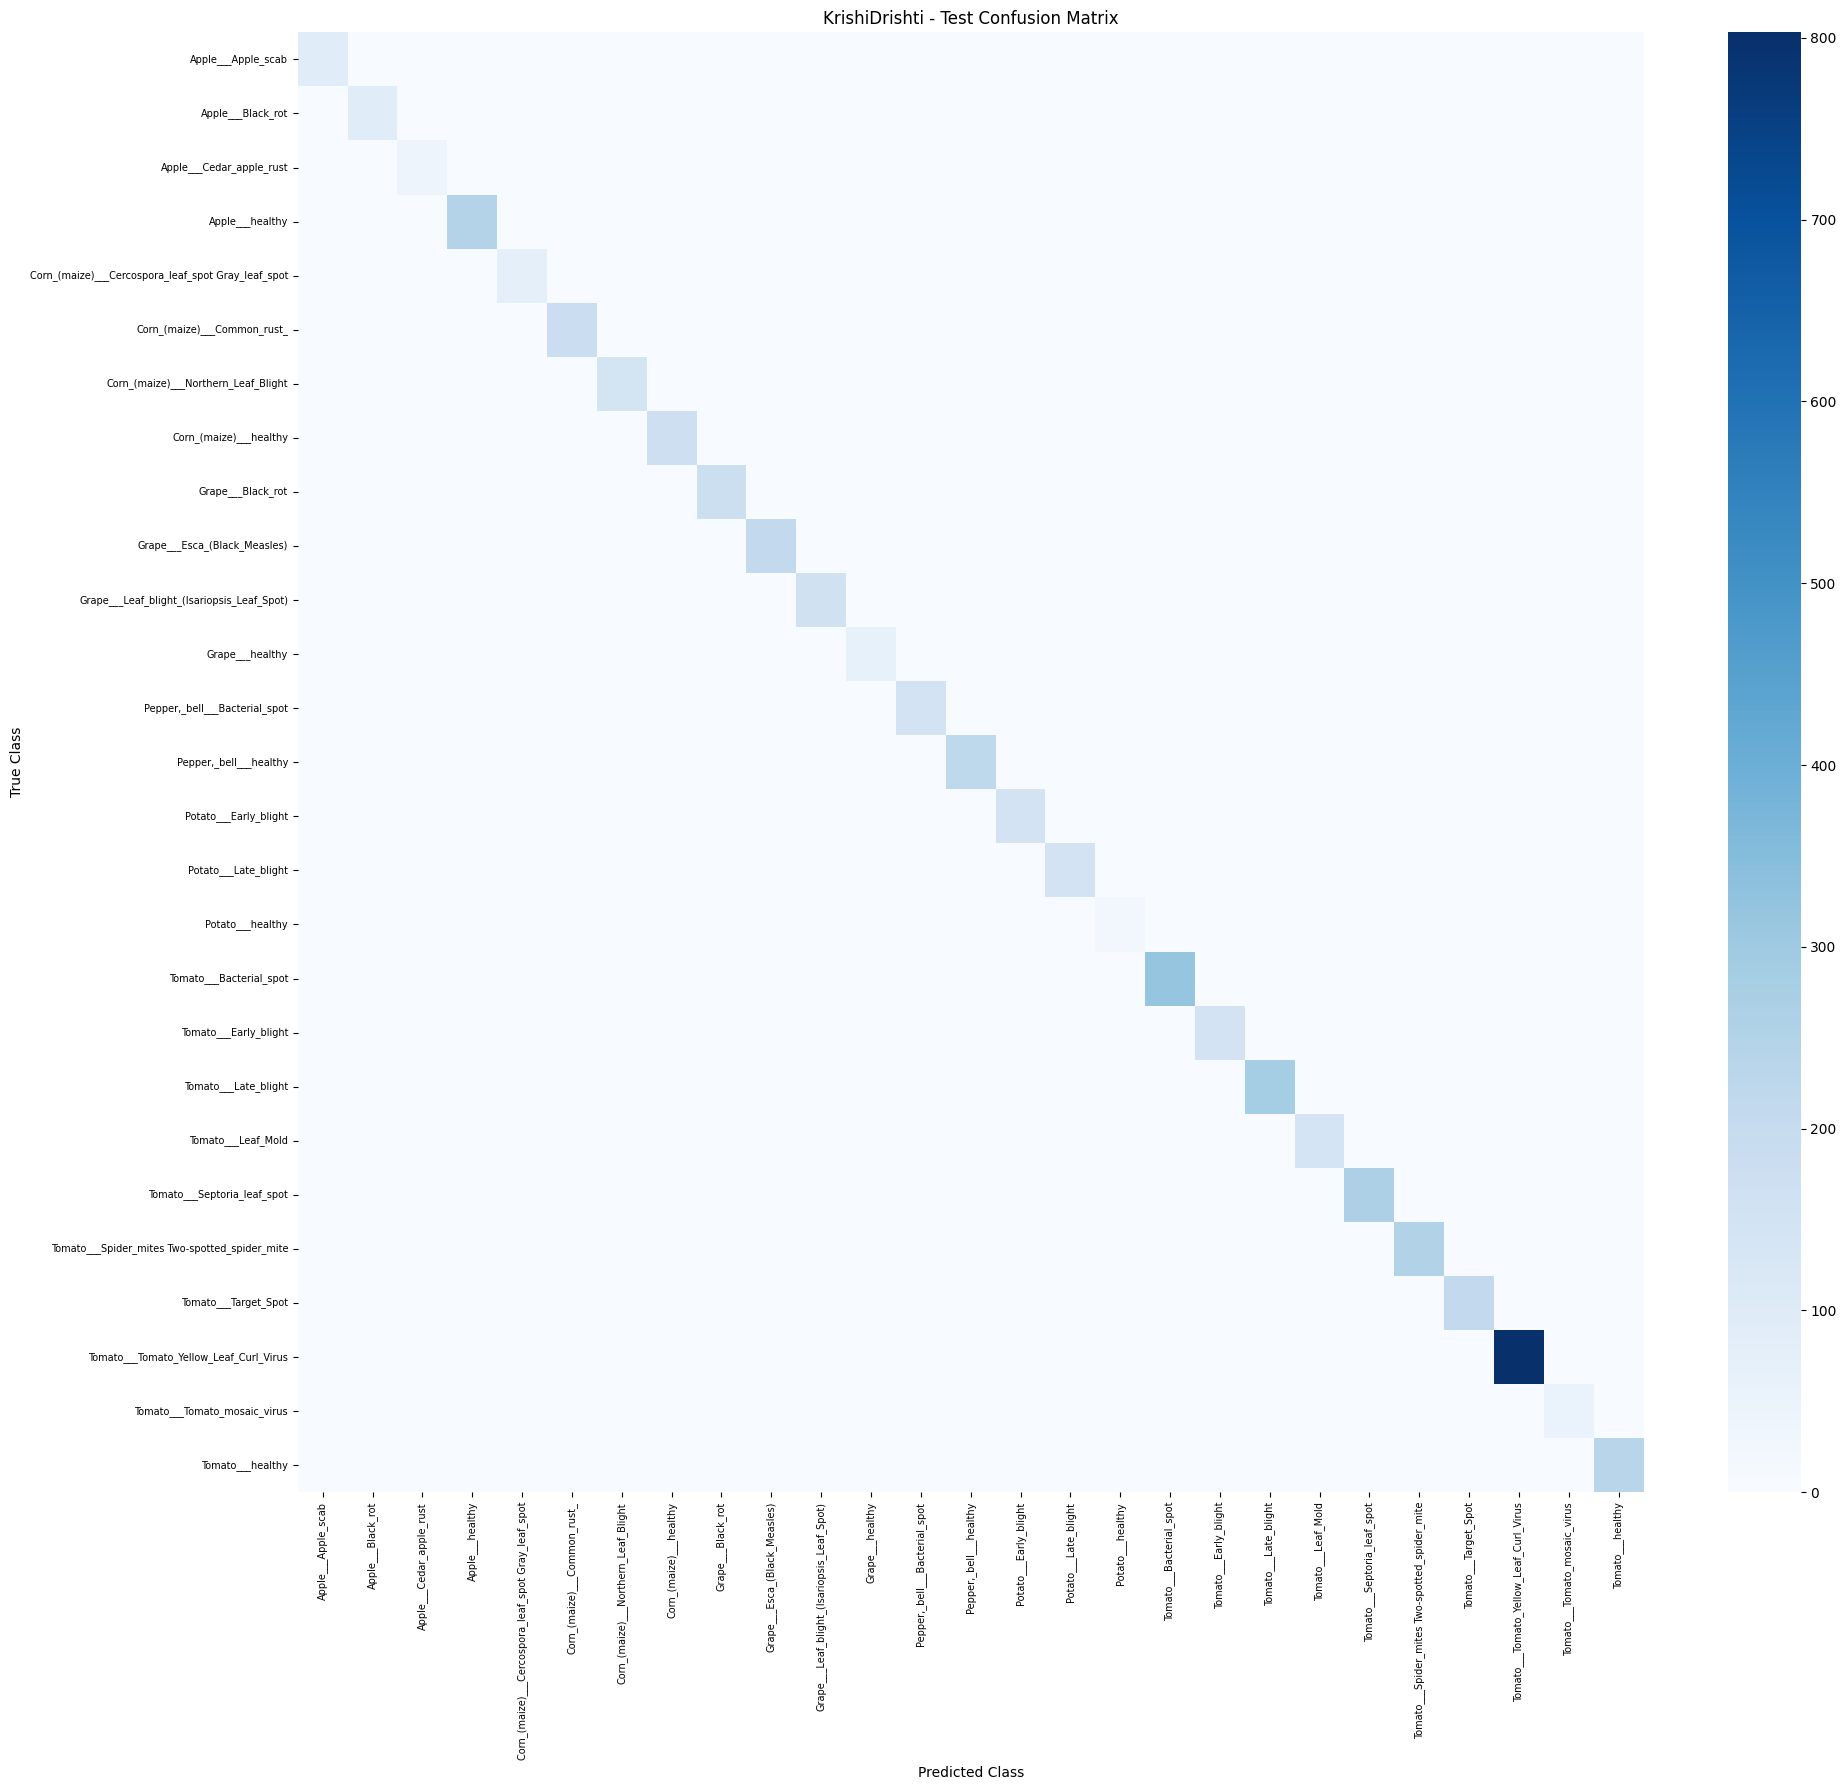

Saved: /content/drive/MyDrive/KrishiDrishti/results/confusion_matrix.png


In [55]:
cm = confusion_matrix(
    all_test_labels,
    all_test_preds
)

plt.figure(
    figsize=(20, 18)
)

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "KrishiDrishti - Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.yticks(
    rotation=0,
    fontsize=7
)

plt.tight_layout()

CONFUSION_PATH = os.path.join(
    DIRS["results"],
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CONFUSION_PATH
)

In [56]:
HISTORY_PATH = os.path.join(
    DIRS["results"],
    "training_history.json"
)

with open(
    HISTORY_PATH,
    "w"
) as f:

    json.dump(
        stage2_history,
        f,
        indent=4
    )

print(
    "Training history saved:"
)

print(HISTORY_PATH)

Training history saved:
/content/drive/MyDrive/KrishiDrishti/results/training_history.json


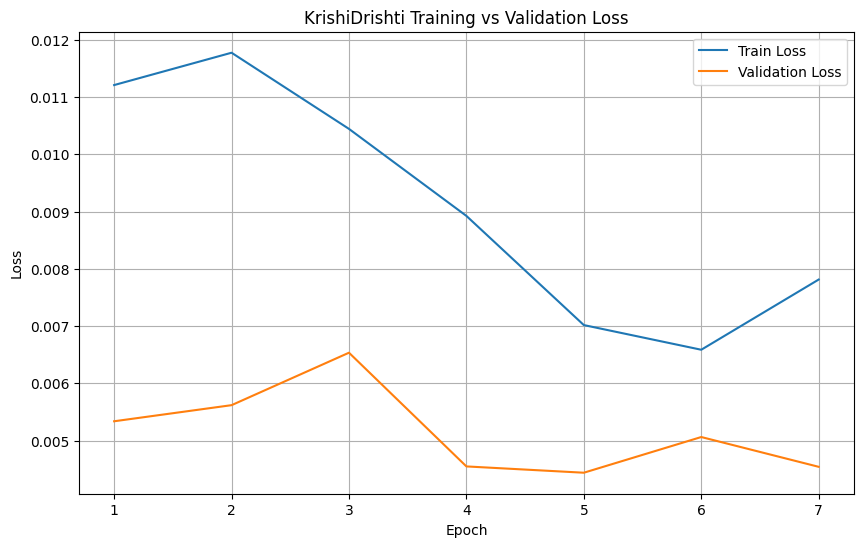

Saved: /content/drive/MyDrive/KrishiDrishti/results/loss_curve.png


In [57]:
epochs = range(
    1,
    len(stage2_history["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    stage2_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    stage2_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "KrishiDrishti Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

LOSS_PLOT = os.path.join(
    DIRS["results"],
    "loss_curve.png"
)

plt.savefig(
    LOSS_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_PLOT)

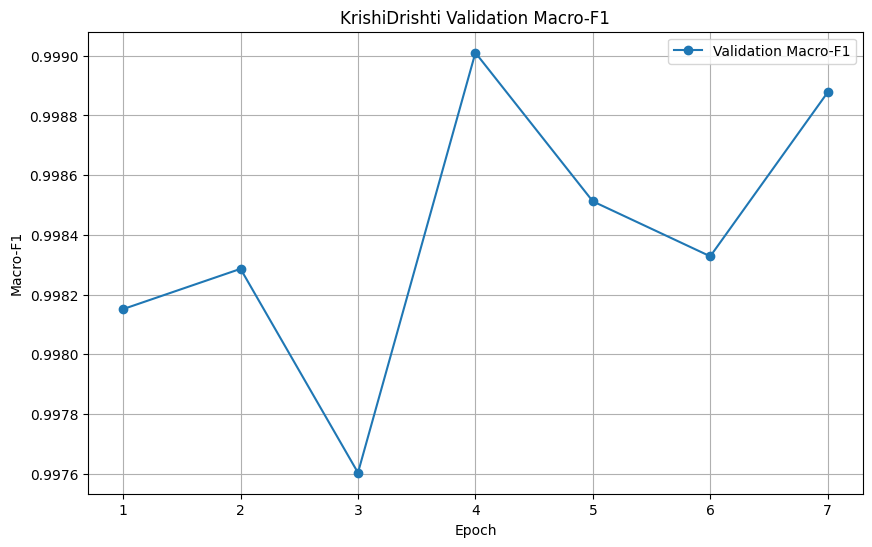

Saved: /content/drive/MyDrive/KrishiDrishti/results/validation_macro_f1.png


In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    stage2_history["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "KrishiDrishti Validation Macro-F1"
)

plt.legend()
plt.grid(True)

F1_PLOT = os.path.join(
    DIRS["results"],
    "validation_macro_f1.png"
)

plt.savefig(
    F1_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", F1_PLOT)

In [59]:
FINAL_MODEL_PATH = os.path.join(
    DIRS["models"],
    "krishidrishti_efficientnet_b0_final.pth"
)

model.eval()

final_package = {

    "model_name":
        "EfficientNet-B0",

    "num_classes":
        len(class_names),

    "class_names":
        class_names,

    "class_to_idx":
        class_to_idx,

    "idx_to_class":
        idx_to_class,

    "image_size":
        IMAGE_SIZE,

    "best_validation_macro_f1":
        float(
            best_checkpoint[
                "best_val_f1"
            ]
        ),

    "test_metrics":
        {
            key: float(value)
            for key, value
            in test_metrics.items()
        },

    "model_state_dict":
        model.state_dict()
}

torch.save(
    final_package,
    FINAL_MODEL_PATH
)

print("✅ FINAL MODEL SAVED")
print("=" * 70)
print(FINAL_MODEL_PATH)

✅ FINAL MODEL SAVED
/content/drive/MyDrive/KrishiDrishti/models/krishidrishti_efficientnet_b0_final.pth


In [62]:
verification = torch.load(
    FINAL_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print("Model verification successful!")
print("=" * 70)

print(
    "Model:",
    verification["model_name"]
)

print(
    "Classes:",
    verification["num_classes"]
)

print(
    "Image size:",
    verification["image_size"]
)

print(
    "Validation Macro-F1:",
    verification[
        "best_validation_macro_f1"
    ]
)

print(
    "Test Macro-F1:",
    verification[
        "test_metrics"
    ]["macro_f1"]
)

print(
    "Test Accuracy:",
    verification[
        "test_metrics"
    ]["accuracy"]
)

Model verification successful!
Model: EfficientNet-B0
Classes: 27
Image size: 224
Validation Macro-F1: 0.9990101702533362
Test Macro-F1: 0.9978211205052067
Test Accuracy: 0.9986215045293423


Saving grape4.jpg.jpeg to grape4.jpg.jpeg


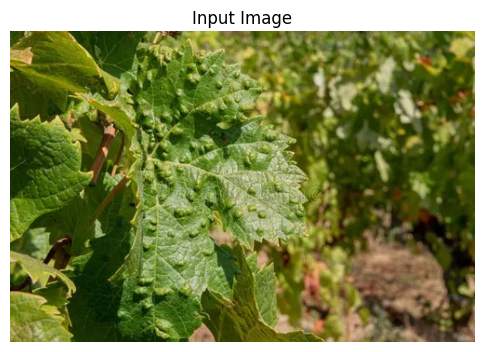

KRISHIDRISHTI — MODEL PREDICTION
Top 1: Grape___Black_rot
Confidence: 94.44%
----------------------------------------------------------------------
Top 2: Grape___Esca_(Black_Measles)
Confidence: 1.75%
----------------------------------------------------------------------
Top 3: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Confidence: 1.31%
----------------------------------------------------------------------
FINAL PREDICTION: Grape___Black_rot
CONFIDENCE: 94.44%


In [77]:
# ============================================================
# TEST NEW MODEL — Upload an image and get prediction
# ============================================================

from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

image_path = next(iter(uploaded.keys()))
image = Image.open(image_path).convert("RGB")

# Use the same validation/test preprocessing
input_tensor = eval_transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probabilities = F.softmax(output, dim=1)

# Top-3 predictions
top_probs, top_indices = torch.topk(probabilities, k=3, dim=1)

top_probs = top_probs[0].cpu().numpy()
top_indices = top_indices[0].cpu().numpy()

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Display results
print("=" * 70)
print("KRISHIDRISHTI — MODEL PREDICTION")
print("=" * 70)

for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
    print(f"Top {rank}: {class_names[idx]}")
    print(f"Confidence: {prob * 100:.2f}%")
    print("-" * 70)

print(f"FINAL PREDICTION: {class_names[top_indices[0]]}")
print(f"CONFIDENCE: {top_probs[0] * 100:.2f}%")

In [ ]:
# ============================================================
# DEFINE EVALUATION TRANSFORM
# ============================================================

from torchvision import transforms

IMAGE_SIZE = 224

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Evaluation transform ready.")

In [73]:
# ============================================================
# KRISHIDRISHTI — INVALID IMAGE ROBUSTNESS TEST
# ============================================================

from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import os

# ------------------------------------------------------------
# Upload multiple invalid / non-leaf images
# ------------------------------------------------------------

print("Upload invalid images for testing.")
print("Examples: person, animal, car, building, food, landscape, etc.")

uploaded = files.upload()

results = []

# ------------------------------------------------------------
# Test every uploaded image
# ------------------------------------------------------------

model.eval()

for filename in uploaded.keys():

    try:
        image = Image.open(filename).convert("RGB")

        # Same preprocessing used by the trained model
        input_tensor = eval_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)

        # Top 3 predictions
        top_probs, top_indices = torch.topk(
            probabilities, k=min(3, len(class_names)), dim=1
        )

        top_probs = top_probs[0].cpu().numpy()
        top_indices = top_indices[0].cpu().numpy()

        prediction = class_names[top_indices[0]]
        confidence = float(top_probs[0] * 100)

        # Robustness warning
        if confidence >= 90:
            status = "⚠️ HIGH CONFIDENCE — POSSIBLE ISSUE"
        elif confidence >= 70:
            status = "⚠️ MODERATE CONFIDENCE"
        else:
            status = "✅ LOWER CONFIDENCE"

        results.append({
            "Image": filename,
            "Prediction": prediction,
            "Confidence (%)": round(confidence, 2),
            "Status": status,
            "Top-2": class_names[top_indices[1]],
            "Top-2 (%)": round(float(top_probs[1] * 100), 2),
            "Top-3": class_names[top_indices[2]],
            "Top-3 (%)": round(float(top_probs[2] * 100), 2)
        })

        # ----------------------------------------------------
        # Display image + prediction
        # ----------------------------------------------------

        plt.figure(figsize=(6, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Prediction: {prediction}\n"
            f"Confidence: {confidence:.2f}%"
        )
        plt.show()

        print(f"Image: {filename}")
        print(f"Prediction : {prediction}")
        print(f"Confidence : {confidence:.2f}%")
        print(f"Status     : {status}")
        print("-" * 70)

    except Exception as e:
        print(f"❌ Could not process {filename}: {e}")


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

if results:

    results_df = pd.DataFrame(results)

    print("\n")
    print("=" * 100)
    print("KRISHIDRISHTI — INVALID IMAGE ROBUSTNESS SUMMARY")
    print("=" * 100)

    display(results_df)

    print("\nHigh-confidence invalid predictions:")

    high_conf = results_df[
        results_df["Confidence (%)"] >= 90
    ]

    if len(high_conf) > 0:
        print(
            f"⚠️ {len(high_conf)} of {len(results_df)} "
            "invalid images received ≥90% confidence."
        )
        print("These cases should be investigated.")
    else:
        print(
            f"✅ No invalid image received ≥90% confidence "
            f"({len(results_df)} images tested)."
        )

else:
    print("No images were successfully tested.")

Upload invalid images for testing.
Examples: person, animal, car, building, food, landscape, etc.


KeyboardInterrupt: 